In [260]:
import json
import pandas as pd
import re
import numpy as np

with open('games.json', encoding="utf8") as file:
    d=json.loads(file.read())

new_games_df = pd.DataFrame.from_dict(d).T.drop(['affiliate_links', 'backloggd_link', 'content', 'submitted_by', 'twitter_ids'], axis=1)
new_games_df["game"] = new_games_df['answers'].apply(lambda x: x[0])
new_games_df = new_games_df.drop(['answers'], axis=1)

def clear_platforms(x):
    x = re.sub(r'\(.*\)', '', x)
    if x.startswith('2020: PC'):
        return ['PC']
    x = x.replace(".", ",")
    x = x.split(",")
    x = [s.strip() for s in x]
    x = ["PS1" if s == "PS" else s for s in x]
    x = ["X360" if s == "360" else s for s in x]
    x = ["GameCube" if s == "Gamecube" else s for s in x]
    x = ["Xbox Series" if s == "X Series X/S" else s for s in x]
    x = ["Xbox Series" if s == "Series X/S" else s for s in x]
    x = ["Xbox Series" if s == "Xbox series" else s for s in x]
    x = ["Xbox Series" if s == "X Series" else s for s in x]
    x = ["Xbox 360" if s == "X360" else s for s in x]
    x = ["Xbox One" if s == "XONE" else s for s in x]
    x = ["Xbox One" if s == "XOne" else s for s in x]
    x = ["Mac" if s == "Macintosh" else s for s in x]
    return x

new_games_df["console_platform"] = new_games_df["console_platform"].apply(clear_platforms)

def clear_genres(x):
    x = re.sub(r'\(.*\)', '', x)
    x = x.replace(".", ",")
    x = x.split(",")
    x = [s.strip().casefold() for s in x]
    return x

new_games_df["genre"] = new_games_df["genre"].apply(clear_genres)

def clear_metacritic(x):
    if x and x[0].isalpha():
        return None
    x = re.search(r"[0-9]+", x)
    return x.group(0)

new_games_df["metacritic_score"] = new_games_df["metacritic_score"].apply(clear_metacritic)
new_games_df["metacritic_score"] = new_games_df["metacritic_score"].astype(float)

new_games_df["release_year"] = new_games_df["release_year"].apply(lambda x: re.search(r"[0-9]{4}", x).group(0))
new_games_df["release_year"] = new_games_df["release_year"].astype(int)

new_games_df['decade'] = new_games_df.release_year // 10 * 10

new_games_df["day"] = new_games_df.index.astype(int)
new_games_df = new_games_df.set_index('day')

In [262]:
# import results
f01 = open("gtg-januar25.txt", "r", encoding="utf8").read()
f02 = open("gtg-februar25.txt", "r", encoding="utf8").read()
f03 = open("gtg-marec25.txt", "r", encoding="utf8").read()
f04 = open("gtg-april25.txt", "r", encoding="utf8").read()
f05 = open("gtg-may25.txt", "r", encoding="utf8").read()
f06 = open("gtg-jun25.txt", "r", encoding="utf8").read()
f07 = open("gtg-jul25.txt", "r", encoding="utf8").read()
f08 = open("gtg-august25.txt", "r", encoding="utf8").read()
f09 = open("gtg-september25.txt", "r", encoding="utf8").read()
f10 = open("gtg-oktober25.txt", "r", encoding="utf8").read()
f11 = open("gtg-november25.txt", "r", encoding="utf8").read()
f12 = open("gtg-december25.txt", "r", encoding="utf8").read()


fulltext = '\n'.join([f01, f02, f03, f04, f05, f06, f07, f08, f09, f10, f11, f12])

# specify beggining and end
from_day = 963
to_day = 1327

fulltext = fulltext.replace("\n\n —", " —") # fix for new Discord badges


pasted = re.findall(".* — [^#—]+#GuessTheGame #[0-9]*\n\n🎮(?:\s*[🟥🟨🟩⬜]){6}|#GuessTheGame #[0-9]*\n\n🎮(?:\s*[🟥🟨🟩⬜]){6}", fulltext)
pasted_all = re.findall("#GuessTheGame #[0-9]*\n\n🎮(?:\s*[🟥🟨🟩⬜]){6}", fulltext)

df = pd.DataFrame(pasted, columns=['full'])
df['name'] = df['full'].apply(lambda x: x.split(" — ")[0].strip()  if "—" in x else None)

df['day'] = df['full'].apply(lambda x: re.findall("#[0-9]+", x)[0][1:])
df['day'] = df['day'].astype(int)

df['guess'] = df['full'].apply(lambda x: re.findall("[🟥🟨🟩⬜]", x).index("🟩") if "🟩" in re.findall("[🟥🟨🟩⬜]", x) else np.nan)

df['score'] = ((df['guess']) * -1) + 6
df['score'].loc[np.isnan(df['score'])] = 0

df['days played'] = 1

df['guess'] = df['guess'] + 1

df['guess'].loc[np.isnan(df['guess'])] = 7

df = df.ffill()

df = df[(df.day >= from_day) & (df.day <= to_day)]

df = df.drop_duplicates(subset=['day', 'name'], keep='first')

# TODO: assert there are no duplicates

difficulty_index = df.groupby(['day']).agg({'score':'sum'}).sort_values(by='score')
difficulty_index = difficulty_index.rename(columns={"score": "day_difficulty"})
difficulty_index_copy = difficulty_index.copy()
difficulty_index_copy.loc[difficulty_index_copy["day_difficulty"] == 0, "day_difficulty"] = 1.0

df = df.join(difficulty_index_copy, on='day')

df['AW hipster score'] = (df['score'] / df['day_difficulty'] * 100).astype(int)

df = df.join(new_games_df, on='day')

df['decade'] = df['release_year'].apply(lambda x: x // 10 * 10)

df_final = df.groupby(['name']).agg({'score':'sum', 'days played':'sum', 'guess':'mean'}).sort_values(by='score', ascending=False)
df_final['guess'] = df_final['guess'].round(2)
df_final = df_final.rename(columns={"guess": "mean correct guess", "score": "total score"})
#df_final['median correct guess'] = df.groupby(['name']).agg({'guess':'median'}).astype(int)
df_final["total score"] = df_final["total score"].astype(int)
df_final = df_final.reset_index()
df_final.index += 1
df_final

,name,total score,days played,mean correct guess
1,yablko,1110,340,3.74
2,Joey Vancouver,991,365,4.28
3,boomer,978,362,4.30
4,eniac,966,359,4.31
5,Hades🐍,962,364,4.36
6,hostinko,721,365,5.02
7,Shape1ess,689,363,5.10
8,HusKy,657,361,5.18
9,Mako,643,249,4.42
10,Celo,634,364,5.26


In [264]:
len(df[df.score == 6])

537

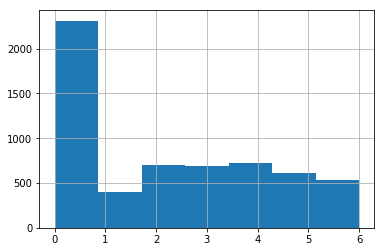

In [269]:
df.score.hist(bins=7)

In [287]:
unique, counts = np.unique(df.score, return_counts=True)
guesses = pd.DataFrame({'Name': unique, 'counts': counts}).sort_values(by='Name', ascending=False)

Text(0, 0.5, 'Count')

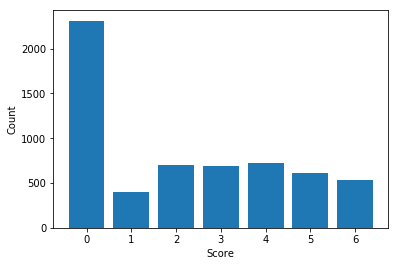

In [290]:
plt.bar(guesses.Name, guesses.counts)
plt.xlabel("Score")
plt.ylabel('Count')

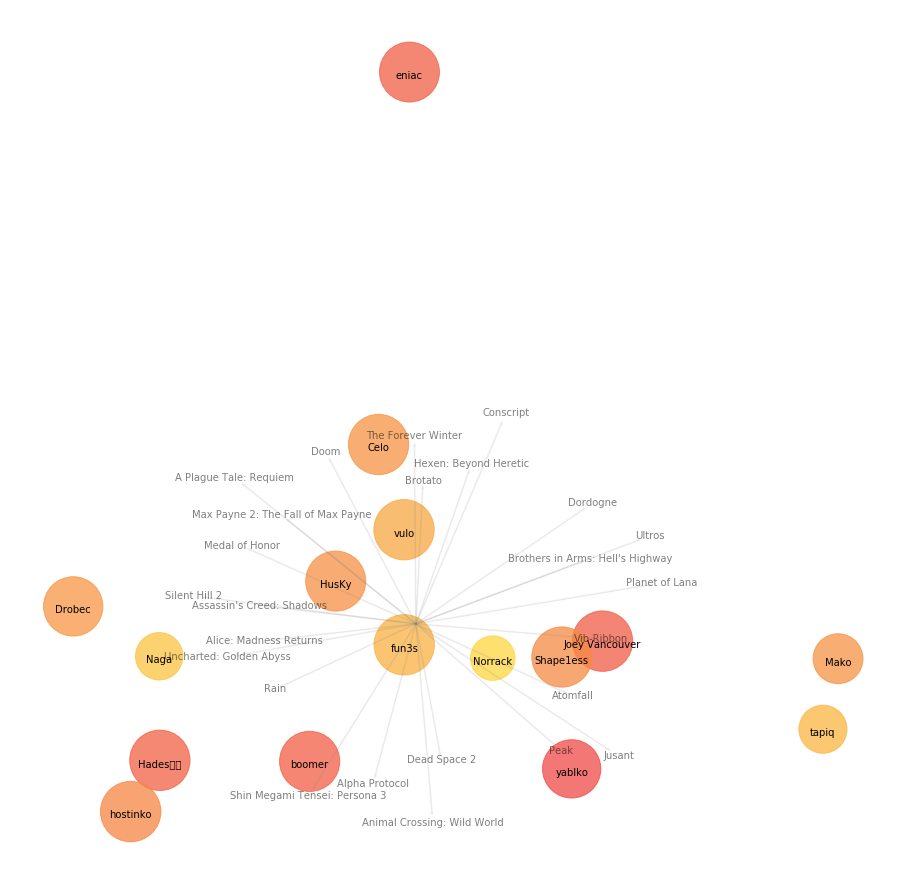

In [230]:
from sklearn import decomposition
import matplotlib.pyplot as plt

hracikovia = list(df_final.name[df_final["days played"] >= 150])
to_pivot = df[df.name.isin(hracikovia)][["name", "score", "game"]]
pivoted = to_pivot.pivot_table(index="name", columns="game", values="score")
pivoted = pivoted.fillna(value=0)

pca = decomposition.PCA(n_components=3)
pca.fit(pivoted)
pca_X = pca.transform(pivoted)

hracikovia_data = df_final.set_index('name').loc[pivoted.index]

import matplotlib
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ["#FDD640","#EF4A46"])

def myplot(score,coeff,labels=None):
    fig = plt.figure(1, figsize=(16, 16))
    plt.clf()

    ax = fig.add_subplot(111)

    xs = score[:,0]
    ys = score[:,1]
    n = coeff.shape[0]
    scalex = 1.0/(xs.max() - xs.min())
    scaley = 1.0/(ys.max() - ys.min())
    sc = ax.scatter(xs * scalex,ys * scaley, c=hracikovia_data['total score'], s=hracikovia_data['days played'] * 10, cmap=cmap, alpha=0.75)
    for i, txt in enumerate(pivoted.index):
        ax.annotate(txt, (xs[i] * scalex, ys[i] * scaley - 0.005), fontsize=10, ha='center', va='center')

    for i in range(n):
        if ((coeff[i,0]**2 + coeff[i,1]**2)**0.5) > 0.10:
            draw = True
            for j in range(i):
                if (((coeff[j,0]-coeff[i,0])**2 + (coeff[i,1]-coeff[j,1])**2)**0.5) < 0.024:
                    draw = False
                    break
            if draw == False:
                continue
            ax.arrow(0, 0, coeff[i,0] * 1.75, coeff[i,1] * 1.75,color = 'gray', alpha = 0.1)
            if labels is None:
                ax.text(coeff[i,0]* 1.85, coeff[i,1] * 1.85, "Var"+str(i+1), color = 'black', ha = 'center', va = 'center', alpha = 0.5)
            else:
                ax.text(coeff[i,0]* 1.85, coeff[i,1] * 1.85, labels[i], color = 'black', ha = 'center', va = 'center', alpha = 0.5)

    ax.xaxis.set_ticklabels([])
    ax.yaxis.set_ticklabels([])

    return sc



#Call the function. Use only the 2 PCs.
sc = myplot(pca_X[:,1:3],np.transpose(pca.components_[1:3]), labels=pivoted.columns)
#plt.xlim(-0.6, 0.6)
#plt.ylim(-0.6, 0.6)
#plt.colorbar(sc, label='Total Score in 2025')
#plt.grid()
plt.axis('off')
plt.show()

In [231]:
df_xbox = df[df.console_platform.apply(lambda x: ['Xbox'] == x or
                                           ['Xbox 360'] == x or
                                           ['Xbox One'] == x or
                                           ['Xbox Series'] == x)]

df_final_xbox = df_xbox.groupby(['name']).agg({'score':'sum', 'days played':'sum', 'guess':'mean'}).sort_values(by='score', ascending=False)
df_final_xbox['guess'] = df_final_xbox['guess'].round(2)
df_final_xbox = df_final_xbox.drop(columns=["guess"])
df_final_xbox["score"] = df_final_xbox["score"].astype(int)
df_final_xbox = df_final_xbox.reset_index()
df_final_xbox.index += 1
df_final_xbox.head(10)

,name,score,days played
1,yablko,35,11
2,boomer,31,11
3,hostinko,27,11
4,HusKy,24,11
5,Joey Vancouver,23,11
6,Celo,21,11
7,Mako,20,8
8,myster,20,5
9,Drobec,19,11
10,Hades🐍,17,11


In [233]:
df_pc = df[df.console_platform.apply(lambda x: ['PC'] == x)]

df_final_pc = df_pc.groupby(['name']).agg({'score':'sum', 'days played':'sum', 'guess':'mean'}).sort_values(by='score', ascending=False)
df_final_pc['guess'] = df_final_pc['guess'].round(2)
df_final_pc = df_final_pc.drop(columns=["guess"])
df_final_pc["score"] = df_final_pc["score"].astype(int)
df_final_pc = df_final_pc.reset_index()
df_final_pc.index += 1
df_final_pc.head(10)

,name,score,days played
1,yablko,138,44
2,Joey Vancouver,128,47
3,Mako,104,30
4,Hades🐍,102,47
5,boomer,101,47
6,eniac,98,46
7,Shape1ess,95,47
8,vulo,87,46
9,Celo,86,47
10,hostinko,68,47


In [234]:
df_ps = df[df.console_platform.apply(lambda x: ['PS1'] == x or
                                           ['PS2'] == x or
                                           ['PS3'] == x or
                                           ['PS4'] == x or
                                           ['PS5'] == x or
                                           ['PSP'] == x or
                                           ['PS Vita'] == x)]

df_final_ps = df_ps.groupby(['name']).agg({'score':'sum', 'days played':'sum', 'guess':'mean'}).sort_values(by='score', ascending=False)
df_final_ps['guess'] = df_final_ps['guess'].round(2)
df_final_ps = df_final_ps.drop(columns=["guess"])
df_final_ps["score"] = df_final_ps["score"].astype(int)
df_final_ps = df_final_ps.reset_index()
df_final_ps.index += 1
df_final_ps.head(10)

,name,score,days played
1,boomer,171,56
2,Hades🐍,164,56
3,yablko,158,53
4,Joey Vancouver,132,56
5,eniac,130,54
6,HusKy,114,56
7,hostinko,102,56
8,Drobec,94,54
9,Celo,92,56
10,kronoss,72,21


In [235]:
df_n = df[df.console_platform.apply(lambda x: ['GameCube'] == x or
                                           ['Wii'] == x or
                                           ['Wii U'] == x or
                                           ['Switch'] == x or
                                           ['DS'] == x or
                                           ['SNES'] == x or
                                           ['NES'] == x or
                                           ['N64'] == x or
                                           ['GBA'] == x or
                                           ['3DS'] == x or
                                           ['Switch 2'] == x)]

df_final_n = df_n.groupby(['name']).agg({'score':'sum', 'days played':'sum', 'guess':'mean'}).sort_values(by='score', ascending=False)
df_final_n['guess'] = df_final_n['guess'].round(2)
df_final_n = df_final_n.drop(columns=["guess"])
df_final_n["score"] = df_final_n["score"].astype(int)
df_final_n = df_final_n.reset_index()
df_final_n.index += 1
df_final_n.head(10)

,name,score,days played
1,boomer,107,40
2,yablko,102,38
3,myster,93,23
4,Hades🐍,86,40
5,Joey Vancouver,85,40
6,Shape1ess,83,40
7,eniac,67,40
8,fun3s,62,40
9,hostinko,61,40
10,Celo,60,40


In [236]:
df_semafor = df[df.score == 4]
df_semafor = df_semafor[df_semafor.full.apply(lambda x: '🟨' in x and '🟥' in x and (x.find('🟥') < x.find('🟨')))]

unique, counts = np.unique(df_semafor.name, return_counts=True)
pd.DataFrame({'Name': unique, 'semaphores': counts}).sort_values(by='semaphores', ascending=False).set_index('Name')

,semaphores
Name,
boomer,16
Hades🐍,14
Joey Vancouver,11
Celo,10
hostinko,9
Shape1ess,9
yablko,7
HusKy,6
vulo,6


In [237]:
df_near_miss = df[df.score == 0]
df_near_miss = df_near_miss[df_near_miss.full.apply(lambda x: '🟨' in x)]

unique, counts = np.unique(df_near_miss.name, return_counts=True)
pd.DataFrame({'Name': unique, 'near misses 🟨': counts}).sort_values(by='near misses 🟨', ascending=False).set_index('Name')

,near misses 🟨
Name,
vulo,20
HusKy,19
fun3s,18
Celo,16
Mako,12
Hades🐍,11
Joey Vancouver,11
hostinko,11
tapiq,10


In [238]:
df_bozemoj = df[df.score == 0]
df_bozemoj = df_bozemoj[df_bozemoj.full.apply(lambda x: x.count('🟨') == 6)]

unique, counts = np.unique(df_bozemoj.name, return_counts=True)
pd.DataFrame({'Name': unique, 'bozemoj count': counts}).sort_values(by='bozemoj count', ascending=False).set_index('Name')

,bozemoj count
Name,
Joey Vancouver,3
Alex,1
Celo,1
Mako,1
hostinko,1
vulo,1


In [239]:
df_bozemoj[['name', 'day', 'game']]

,name,day,game
160,Joey Vancouver,971,Crash Bandicoot: The Wrath of Cortex
320,hostinko,979,Shin Megami Tensei V
321,Alex,979,Shin Megami Tensei V
329,Joey Vancouver,979,Shin Megami Tensei V
1371,Mako,1035,Mario & Luigi: Superstar Saga
4613,vulo,1228,Spider-man 2
4649,Joey Vancouver,1228,Spider-man 2
5998,Celo,1321,Castlevania II: Simon's Quest


In [240]:
difficulty_index.join(new_games_df['game'], on='day').head(9)

,day_difficulty,game
day,,
1221,0.0,Bound by Flame
1004,0.0,Spiral Knights
1111,0.0,The Legend of Dragoon
1282,0.0,Custom Robo
1093,0.0,Odama
1260,0.0,Vandal Hearts II
1169,0.0,Beacon Pines
1204,0.0,Billy Hatcher and the Giant Egg
1246,0.0,Afterimage


In [241]:
difficulty_index.join(new_games_df['game'], on='day').sort_values(by='day_difficulty', ascending=False).head(10)

,day_difficulty,game
day,,
1026,110.0,Mario Tennis Aces
977,101.0,Sid Meier's Civilization IV
999,96.0,Final Fantasy X
1207,96.0,NBA Jam
1304,94.0,Wolfenstein: The New Order
1028,92.0,Super Mario Bros. 2
993,91.0,Super Mario World
1017,91.0,Assassin's Creed Origins
982,90.0,Super Mario 3D World


In [246]:
difficulty_index.join(new_games_df, on='day').sort_values(by='day_difficulty', ascending=False).groupby("decade")['day_difficulty'].mean().round(1)

decade
1980    31.4
1990    38.8
2000    31.5
2010    37.2
2020    37.0
Name: day_difficulty, dtype: float64

In [205]:
from IPython.display import display, HTML
pd.set_option('display.max_colwidth', 255)

def pretty_print(df):
    return display( HTML( df.to_html().replace("\\n","<br>") ) )

hipster_score_2 = df.copy().groupby(['name','AW hipster score'])['game'].apply(lambda x: '\n'.join(x.sort_values())).reset_index().sort_values(by=['AW hipster score', 'name'], ascending=[False, True]).drop_duplicates(['name'])
hipster_score_2.index = np.arange(len(hipster_score_2)) + 1
hipster_score_2 = hipster_score_2[hipster_score_2["AW hipster score"] == 100].drop(columns=['AW hipster score'])
pretty_print(hipster_score_2.set_index('name'))

,game
name,
Celo,The Cat Lady
Drobec,R.E.P.O
Joey Vancouver,El Shaddai: Ascension of the Metatron
Than3s,Fantasy Life i: The Girl Who Steals Time
Tulex,The Hundred Line: Last Defense Academy
boomer,Brave Fencer MusashiDark SectorDevil's ThirdFolkloreResonance of Fate
eniac,Darkstalkers 3Eternal ChampionsSlave Zero XThe Forever Winter
hostinko,BattleBlock Theater
myster,Crab GameDark EarthOkage: Shadow KingStar Ocean: Till the End of Time


In [214]:
from IPython.display import display, HTML
pd.set_option('display.max_colwidth', 255)

def pretty_print(df):
    return display( HTML( df.to_html().replace("\\n","<br>") ) )

hipster_score_2 = df.copy().groupby(['name','AW hipster score'])['game'].apply(lambda x: '\n'.join(x)).reset_index().sort_values(by=['AW hipster score', 'name'], ascending=[False, True]).drop_duplicates(['name'])
hipster_score_2.index = np.arange(len(hipster_score_2)) + 1
pretty_print(hipster_score_2[hipster_score_2["AW hipster score"] > 0].set_index('name'))

,AW hipster score,game
name,,
Celo,100,The Cat Lady
Drobec,100,R.E.P.O
Joey Vancouver,100,El Shaddai: Ascension of the Metatron
Than3s,100,Fantasy Life i: The Girl Who Steals Time
Tulex,100,The Hundred Line: Last Defense Academy
boomer,100,Devil's ThirdBrave Fencer MusashiDark SectorFolkloreResonance of Fate
eniac,100,Slave Zero XThe Forever WinterDarkstalkers 3Eternal Champions
hostinko,100,BattleBlock Theater
myster,100,Okage: Shadow KingStar Ocean: Till the End of TimeDark EarthCrab Game
